# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [3]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


In [4]:
df.info

<bound method DataFrame.info of       Age  Gender      Income            Education Marital Status  \
0    25.0  Female   50.000,00    Bachelor's Degree         Single   
1    30.0    Male  100.000,00      Master's Degree        Married   
2    35.0  Female   75.000,00            Doctorate        Married   
3    40.0    Male  125.000,00  High School Diploma         Single   
4    45.0  Female  100.000,00    Bachelor's Degree        Married   
..    ...     ...         ...                  ...            ...   
159  29.0  Female   27.500,00  High School Diploma         Single   
160  34.0    Male   47.500,00   Associate's Degree         Single   
161  39.0  Female   62.500,00    Bachelor's Degree        Married   
162  44.0    Male   87.500,00      Master's Degree         Single   
163  49.0  Female   77.500,00            Doctorate        Married   

     Number of Children Home Ownership Credit Score  
0                     0         Rented         High  
1                     2        

Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [5]:
df.dtypes

Age                   float64
Gender                    str
Income                    str
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

In [6]:
df['Income'] = df['Income'].str.replace('.', '', regex=False)
df['Income'] = df['Income'].str.replace(',', '', regex=False)
df['Income'] = df['Income'].astype(float)

In [16]:
df['Age'] = df['Age'].astype(int)

**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

In [7]:
(df.isnull().sum() / len(df)) * 100

Age                   20.731707
Gender                 0.000000
Income                 0.000000
Education              0.000000
Marital Status         0.000000
Number of Children     0.000000
Home Ownership         0.000000
Credit Score           0.000000
dtype: float64

Nota-se que a coluna 'Age', está com aproximadamente 20% de dados nulos, logo optei por substituir, ao invéz de remove-los já que representam uma porcentagem considerável.

In [8]:
df['Age'].mean()

np.float64(37.50769230769231)

In [9]:
df['Age'].median()

np.float64(36.0)

In [10]:
mediana = df['Age'].median()
df['Age'] = df['Age'].fillna(mediana)

Depois de visualizar o cálculo da média e mediana e perceber que os valores eram muitos próximos, optei por substituir os valores nulos pela mediana de 'Age'.

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [11]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [12]:
df['Education'].unique()

<StringArray>
[  'Bachelor's Degree',     'Master's Degree',           'Doctorate',
 'High School Diploma',  'Associate's Degree']
Length: 5, dtype: str

In [15]:
df['Marital Status'].unique()

<StringArray>
['Single', 'Married']
Length: 2, dtype: str

In [14]:
df['Home Ownership'].unique()

<StringArray>
['Rented', 'Owned']
Length: 2, dtype: str

In [13]:
df['Credit Score'].unique()

<StringArray>
['High', 'Average', 'Low']
Length: 3, dtype: str

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [17]:
df.describe()

,Age,Income,Number of Children
count,164.000000,1.640000e+02,164.000000
mean,37.195122,8.376524e+06,0.652439
std,7.586619,3.245731e+06,0.883346
min,25.000000,2.500000e+06,0.000000
25%,31.750000,5.750000e+06,0.000000
50%,36.000000,8.375000e+06,0.000000
75%,43.000000,1.050000e+07,1.000000
max,53.000000,1.625000e+07,3.000000


In [18]:
fig = px.box(df, y='Age', title='BoxPlot de Age')
fig.show()

In [19]:
fig = px.box(df, y='Income', title='BoxPlot de Income')
fig.show()

In [30]:
fig = px.box(df, y='Number of Children', title='BoxPlot de Number of Children')
fig.show()

In [44]:
contagem = df['Number of Children'].value_counts().reset_index()
contagem.columns = ['Number of Children', 'Frequência']

# Porcentagem
total = contagem['Frequência'].sum()
contagem['Porcentagem'] = (contagem['Frequência'] / total * 100).round(2)

fig = px.bar(contagem, x='Number of Children', y='Frequência', text='Porcentagem', title='Gráfico de Barras para a Variável Number of Children')

# Ajustar texto para mostrar %
fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(xaxis_title='Number of Children', yaxis_title='Frequência')
fig.show()

A função 'describe()', mostra que para as colunas 'Age' e 'Income', os 50% dos dados está bem próximo da média, o que inicialmente indica uma boa distribuição dos dados, e a plotagem dos gráficos boxplot confirmam isso. 

Para a coluna'Number od Children' nota-se que há diferença significativa entre a média e os 50% dos dados. Entretanto, isso está relacionado com o que essa coluna representa na base de dados, ou seja, isso quer dizer que a maior parte das pessoas não possuem filhos. O gráfico boxplot deixa isso bem nítido, e mostra um possíveis outliers, porem não podemos interpretá-los como um, já que o número de filhos é algo relativo, mesmo que somente 5 pessoas posssuam 3 filhos no dataframe.

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

In [37]:
contagem = df['Gender'].value_counts().reset_index()
contagem.columns = ['Gender', 'Frequência']

# Porcentagem
total = contagem['Frequência'].sum()
contagem['Porcentagem'] = (contagem['Frequência'] / total * 100).round(2)

fig = px.bar(contagem, x='Gender', y='Frequência', text='Porcentagem', title='Gráfico de Barras para a Variável Gender')

# Ajustar texto para mostrar %
fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(xaxis_title='Gender', yaxis_title='Frequência')
fig.show()

Nota-se que temos um certo equilíbrio de gêneros, com uma pequena porcentagem maior para o gênero 'Female'.

In [20]:
contagem = df['Education'].value_counts().reset_index()
contagem.columns = ['Education', 'Frequência']

# Porcentagem
total = contagem['Frequência'].sum()
contagem['Porcentagem'] = (contagem['Frequência'] / total * 100).round(2)

fig = px.bar(contagem, x='Education', y='Frequência', text='Porcentagem', title='Gráfico de Barras para a Variável Education')

# Ajustar texto para mostrar %
fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(xaxis_title='Education', yaxis_title='Frequência')
fig.show()

Para a variável 'Education' temos um número maior de pessoas com 'Bachelo's Degree' (25%), mesmo que a diferença entre as categorias não seja alta.

In [41]:
contagem = df['Marital Status'].value_counts().reset_index()
contagem.columns = ['Marital Status', 'Frequência']

# Porcentagem
total = contagem['Frequência'].sum()
contagem['Porcentagem'] = (contagem['Frequência'] / total * 100).round(2)

fig = px.bar(contagem, x='Marital Status', y='Frequência', text='Porcentagem', title='Gráfico de Barras para a Variável Marital Status')

# Ajustar texto para mostrar %
fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(xaxis_title='Marital Status', yaxis_title='Frequência')
fig.show()

Visualiza-se no gráfico que há uma maior porcentagem de 'Married' em 'Marital Status'.

In [42]:
contagem = df['Home Ownership'].value_counts().reset_index()
contagem.columns = ['Home Ownership', 'Frequência']

# Porcentagem
total = contagem['Frequência'].sum()
contagem['Porcentagem'] = (contagem['Frequência'] / total * 100).round(2)

fig = px.bar(contagem, x='Home Ownership', y='Frequência', text='Porcentagem', title='Gráfico de Barras para a Variável Home Ownership')

# Ajustar texto para mostrar %
fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(xaxis_title='Home Ownership', yaxis_title='Frequência')
fig.show()

Há uma predominância de pessoas 'Owned' com aproximadamente 67% dos dados.

In [ ]:
contagem = df['Credit Score'].value_counts().reset_index()
contagem.columns = ['Credit Score', 'Frequência']

# Porcentagem
total = contagem['Frequência'].sum()
contagem['Porcentagem'] = (contagem['Frequência'] / total * 100).round(2)

fig = px.bar(contagem, x='Credit Score', y='Frequência', text='Porcentagem', title='Gráfico de Barras para a Variável Credit Score')

# Ajustar texto para mostrar %
fig.update_traces(texttemplate='%{text}%', textposition='outside')

fig.update_layout(xaxis_title='Credit Score', yaxis_title='Frequência')
fig.show()

Nota-se que no gráfico há um número maior de pessoas com 'High' de 'Credit Score', aproximadamente 68% dos dados.

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

A única coluna que foi encontrado outliers foi a de 'Number of Children'. Porem, assim como dito anteriormente, não podemos tratá-los como outliers, por isso optei por mantê-los. 

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



In [48]:
mediana = df.groupby('Marital Status')['Age'].median().reset_index()

fig = px.bar(mediana, x='Marital Status', y='Age',
            title='Média Age com Marital Status')
fig.show()

Percebe-se que a mediana da idade de pessoas 'Married' é de 37 anos, enquanto que para pessoas 'Single' é de 33 anos, ou seja, pessoas mais velhass tendem a se casar.

In [21]:
df_grouped = df.groupby(['Credit Score', 'Education']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Credit Score')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Credit Score', y='percent', color='Education', barmode='stack',
            labels={'Credit Score': 'Credit Score', 'percent': 'Porcentagem', 'Education': 'Education'})

fig.update_layout(title='Relação entre Credit Score e Education',
                yaxis_title='Porcentagem',
                legend_title='Education')
fig.show()

Visualiza-se que pessoas com baixo nível de score, possuem o nível de escolaridade 'High School Diploma' e 'Associat's Degree'. Já as pessoas com alto score de crédito, em grande maioria, possuem 'Doctorate', 'Master's Degree' e 'Bachelor's Degree'. Portanto, pessoas com maior nível de escolaridade tendem a ter maiores chances de score de crédito alto.

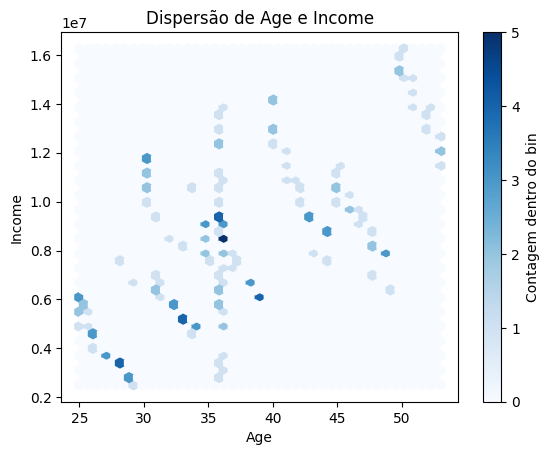

In [25]:
plt.hexbin(df['Age'], df['Income'], gridsize=40 , cmap='Blues')
plt.colorbar(label='Contagem dentro do bin')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Dispersão de Age e Income')
plt.show()

O gráfico de dispersão mostra que há uma oscilação entre idade e 'Income', há pessoas com idades baixas e income altos, e vice-versa.

In [26]:
mediana = df.groupby('Credit Score')['Income'].median().reset_index()

fig = px.bar(mediana, x='Credit Score', y='Income',
            title='Média Income com Credit Score')
fig.show()

Visualiza-se que o salário influencia diretamente o score de crédito, a mediana de salário das pessoas com score 'High' é de (9.5M), enquanto que para clientes com score 'Low' é de (3.25M).

In [27]:
fig = px.histogram(df, x='Credit Score', color='Home Ownership', barmode='stack')
fig.update_layout(title='Relação entre Credit Score e Home Ownership',
                xaxis_title='Credit Score',
                yaxis_title='Contagem',
                legend_title='Home Ownership')
fig.show()

Clientes com casa própia tendem a ter alto score de crédito, o gráfico de barras mostra que quase 100% das pessoas que possuem casa própia tem score 'High' de crédito. Logo, o fator 'Home Ownership' é muito importante para análise liberação de limite crédito para os clientes.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

- Existe relação entre salário e nível de escolaridade?
- Há equilíbrio de genero em diferentes níveis de escolaridade? 
- Mulheres recebem maiores saários que os homens?

In [28]:
mediana = df.groupby('Education')['Income'].median().reset_index()

fig = px.bar(mediana, x='Education', y='Income',
            title='Média Income com Education')
fig.show()

Observa-se que 'Master's Degree' e 'Doctorate' são os níveis de escolaridade com maiores mediana de salário.

In [21]:
df_grouped = df.groupby(['Education', 'Gender']).size().reset_index(name='count')
total_por_churn = df_grouped.groupby('Gender')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / total_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Education', y='percent', color='Gender', barmode='stack',
            labels={'Education': 'Education', 'percent': 'Porcentagem', 'Gender': 'EducGenderation'})

fig.update_layout(title='Relação entre Gender e Education',
                yaxis_title='Porcentagem',
                legend_title='Education')
fig.show()

Nos diferentes níveis de escolaridade, há uma predominancia maior de homens ou mulheres, em nenhum nívvel há um equilíbrio. Em 'Bachelor's Degree' as mulheres são a grande maioria, enquanto que em 'Master's Degree' a maioria são homens.

In [23]:
mediana = df.groupby('Gender')['Income'].median().reset_index()

fig = px.bar(mediana, x='Gender', y='Income',
            title='Média Gender com Income')
fig.show()

Observa-se no gráfico que homens tem mediana salarial maior que as mulheres com (10.5M), já as mulheres possuem (7M).

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

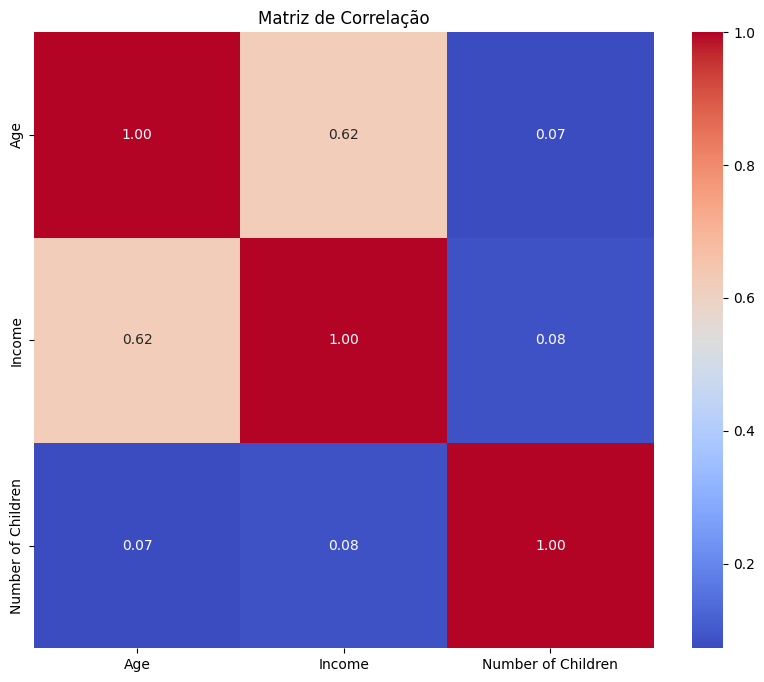

In [18]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

As variáveis idade e salário possuem alta correlação. Isso se deve ao fato de que na maioria das vezes, pessoas mais novas possuem salários baixos que vão aumentanto conforme elas ficam mais velhas, ou seja, a idade influencia diretamente no salário e vice-versa.

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [17]:
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,5000000.0,Bachelor's Degree,Single,0,Rented,High
1,30,Male,10000000.0,Master's Degree,Married,2,Owned,High
2,35,Female,7500000.0,Doctorate,Married,1,Owned,High
3,40,Male,12500000.0,High School Diploma,Single,0,Owned,High
4,45,Female,10000000.0,Bachelor's Degree,Married,3,Owned,High


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

In [ ]:
#seu código aqui

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [ ]:
#seu código aqui

**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

In [ ]:
#seu código aqui

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [ ]:
#seu código aqui